# Normalizing Flow - Stone Throwing with Neural Posterior Estimation

---

This notebook is mostly a port to jax ecosystem of an example introduced in https://arxiv.org/abs/2508.12939v1 and associated github repository (Deistler et al. 2025)

---

This notebook implements an amortized **neural posterior estimation (NPE)** workflow for the stone-throwing example, including the simulator, summary statistics, prior, latent wind, posterior predictive checks, and simulation-based calibration setup.

The observation is compressed to the two summary statistics `(landing distance, flight time)`, and the normalizing flow is trained directly on the posterior $p( \theta | x)$ for the throw angle $\theta$.


In [ ]:
from __future__ import annotations

import math
import time
from dataclasses import dataclass
from functools import partial
from typing import Any, NamedTuple, Tuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

# Compatibility shim for older optax/chex releases against newer JAX arrays.
if not hasattr(jax.interpreters.xla, "DeviceArray"):
    jax.interpreters.xla.DeviceArray = getattr(jax, "Array", type(jnp.asarray(0.0)))

import optax
from flax.training.train_state import TrainState
import flax.linen as nn
from jax import lax, random, vmap

if not hasattr(nn.initializers, "zeros_init"):
    nn.initializers.zeros_init = lambda: nn.initializers.zeros

print("JAX version:", jax.__version__)
print("Device:", jax.devices()[0])

# -----------------------------------------------------------------------------
# Reproducibility and practical runtime defaults
# -----------------------------------------------------------------------------
MASTER_SEED = 42
MASTER_KEY = random.PRNGKey(MASTER_SEED)

NUM_SIMULATIONS = 10_000
MAX_EPOCHS = 200
NUM_SBC_SAMPLES = 200
NUM_SBC_POSTERIOR_SAMPLES = 1_000

NUM_POSTERIOR_SAMPLES = 1_000
NUM_PPC_SAMPLES = 110
NUM_PPC_HIGHLIGHT = 10
NUM_PRIOR_PREDICTIVE_SAMPLES = 1_000
NUM_PRIOR_PREDICTIVE_HIGHLIGHT = 10


BATCH_SIZE = 256
# -----------------------------------------------------------------------------
# Ball-throw setup: identical problem definition to the original notebook
# -----------------------------------------------------------------------------
PI = math.pi
DT = 0.5
NOISE_STD = 0.01
MAX_STEPS = 512

PRIOR_MEAN = 35.0
PRIOR_STD = 15.0
WIND_RATE = 200.0  # Exponential rate parameter, so E[W] = 1 / 200 = 0.005

FIXED_STRENGTH = 0.7
FIXED_GRAVITY = 0.05
FIXED_FRICTION = 0.1


JAX version: 0.4.38
Device: TFRT_CPU_0


## Ball Throw Example

The ball-throw simulator models a trajectory $(x(t), y(t))$ starting from the origin.
The unknown parameter of interest is the throw angle $\theta$.
The initial speed $v$, gravity $g$, and friction coefficient $\mu$ are fixed.
Wind $W$ is *latent simulator noise* rather than an inferred parameter.

The dynamics are

$$
\frac{d^2x}{dt^2} = W - \mu \frac{dx}{dt}, \qquad
\frac{d^2y}{dt^2} = -g - \mu \frac{dy}{dt},
$$

with initial conditions

$$
x(0)=0,\quad y(0)=0,\quad
\dot x(0)=v\cos\theta,\quad
\dot y(0)=v\sin\theta.
$$

It uses semi-implicit Euler update and summary-statistics that are noisy flight time and distance.


In [2]:
def step_np(
    x: float,
    y: float,
    dx: float,
    dy: float,
    dt: float,
    gravity: float,
    wind: float,
    friction: float,
) -> tuple[float, float, float, float]:
    friction_x = friction * dx
    friction_y = friction * dy

    ddy = -gravity - friction_y
    dy = dy + ddy * dt

    ddx = wind - friction_x
    dx = dx + ddx * dt

    return x + dx * dt, y + dy * dt, dx, dy


def simulate_np(
    angle: float,
    strength: float,
    gravity: float,
    wind: float,
    friction: float,
    noisy: bool = False,
    dt: float = DT,
    max_steps: int = 10_000,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    xs = [0.0]
    ys = [0.0]

    angle_rad = angle / 180.0 * PI
    dx = np.cos(angle_rad) * strength
    dy = np.sqrt(max(strength**2 - dx**2, 0.0))

    for i in range(max_steps):
        x, y, dx, dy = step_np(xs[-1], ys[-1], dx, dy, dt, gravity, wind, friction)
        xs.append(x)
        ys.append(y)
        if i > 1 and ys[-1] < 0:
            break

    xs = np.asarray(xs, dtype=np.float32)
    ys = np.asarray(ys, dtype=np.float32)
    ts = np.arange(len(xs), dtype=np.float32) * dt

    if noisy:
        if rng is None:
            rng = np.random.default_rng()
        xs = xs + rng.normal(scale=NOISE_STD, size=xs.shape)
        ys = ys + rng.normal(scale=NOISE_STD, size=ys.shape)
        ts = ts + rng.normal(scale=NOISE_STD, size=ts.shape)

    return xs, ys, ts


def summary_stats(
    xs: np.ndarray,
    ys: np.ndarray,
    ts: np.ndarray | None = None,
) -> np.ndarray:
    frac = 1.0 - (ys[-1] / (ys[-1] - ys[-2]))
    landing_x = frac * (xs[-1] - xs[-2]) + xs[-2]
    if ts is None:
        ts = np.arange(len(ys), dtype=np.float32) * DT
    flight_time = frac * (ts[-1] - ts[-2]) + ts[-2]
    return np.asarray([landing_x, flight_time], dtype=np.float32)


# -----------------------------------------------------------------------------
# JAX simulator for batched summary-statistics generation
# -----------------------------------------------------------------------------
def step_jax(
    x: jnp.ndarray,
    y: jnp.ndarray,
    dx: jnp.ndarray,
    dy: jnp.ndarray,
    dt: float,
    gravity: float,
    wind: jnp.ndarray,
    friction: float,
) -> tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    friction_x = friction * dx
    friction_y = friction * dy

    ddy = -gravity - friction_y
    dy = dy + ddy * dt

    ddx = wind - friction_x
    dx = dx + ddx * dt

    return x + dx * dt, y + dy * dt, dx, dy


class SummaryState(NamedTuple):
    x: jnp.ndarray
    y: jnp.ndarray
    dx: jnp.ndarray
    dy: jnp.ndarray
    current_t: jnp.ndarray
    current_x_noisy: jnp.ndarray
    current_y_noisy: jnp.ndarray
    current_t_noisy: jnp.ndarray
    done: jnp.ndarray
    cross_prev_t_noisy: jnp.ndarray
    cross_t_noisy: jnp.ndarray
    cross_prev_x_noisy: jnp.ndarray
    cross_prev_y_noisy: jnp.ndarray
    cross_x_noisy: jnp.ndarray
    cross_y_noisy: jnp.ndarray


def simulate_summary_one(
    key: jax.Array,
    angle: jnp.ndarray,
    strength: float,
    gravity: float,
    wind: jnp.ndarray,
    friction: float,
    dt: float = DT,
    max_steps: int = MAX_STEPS,
    noise_std: float = NOISE_STD,
) -> tuple[jnp.ndarray, jnp.ndarray]:
    angle_rad = angle / 180.0 * PI
    dx0 = jnp.cos(angle_rad) * strength
    dy0 = jnp.sqrt(jnp.maximum(strength**2 - dx0**2, 0.0))

    noise = noise_std * random.normal(key, shape=(max_steps + 1, 3), dtype=jnp.float32)
    x0_noisy = noise[0, 0]
    y0_noisy = noise[0, 1]
    t0_noisy = noise[0, 2]

    state = SummaryState(
        x=jnp.array(0.0, dtype=jnp.float32),
        y=jnp.array(0.0, dtype=jnp.float32),
        dx=dx0.astype(jnp.float32),
        dy=dy0.astype(jnp.float32),
        current_t=jnp.array(0.0, dtype=jnp.float32),
        current_x_noisy=x0_noisy,
        current_y_noisy=y0_noisy,
        current_t_noisy=t0_noisy,
        done=jnp.array(False),
        cross_prev_t_noisy=t0_noisy,
        cross_t_noisy=t0_noisy,
        cross_prev_x_noisy=x0_noisy,
        cross_prev_y_noisy=y0_noisy,
        cross_x_noisy=x0_noisy,
        cross_y_noisy=y0_noisy,
    )

    def body_fn(
        state: SummaryState, inputs: tuple[jnp.ndarray, jnp.ndarray]
    ) -> tuple[SummaryState, None]:
        step_idx, step_noise = inputs
        next_t = step_idx.astype(jnp.float32) * dt
        next_x, next_y, next_dx, next_dy = step_jax(
            state.x, state.y, state.dx, state.dy, dt, gravity, wind, friction
        )
        next_x_noisy = next_x + step_noise[0]
        next_y_noisy = next_y + step_noise[1]
        next_t_noisy = next_t + step_noise[2]

        active = ~state.done
        crossing = active & (step_idx > 1) & (next_y < 0.0)
        cross_prev_t_noisy = jnp.where(
            crossing, state.current_t_noisy, state.cross_prev_t_noisy
        )
        cross_t_noisy = jnp.where(crossing, next_t_noisy, state.cross_t_noisy)

        cross_prev_x_noisy = jnp.where(
            crossing, state.current_x_noisy, state.cross_prev_x_noisy
        )
        cross_prev_y_noisy = jnp.where(
            crossing, state.current_y_noisy, state.cross_prev_y_noisy
        )
        cross_x_noisy = jnp.where(crossing, next_x_noisy, state.cross_x_noisy)
        cross_y_noisy = jnp.where(crossing, next_y_noisy, state.cross_y_noisy)

        new_state = SummaryState(
            x=jnp.where(active, next_x, state.x),
            y=jnp.where(active, next_y, state.y),
            dx=jnp.where(active, next_dx, state.dx),
            dy=jnp.where(active, next_dy, state.dy),
            current_t=jnp.where(active, next_t, state.current_t),
            current_x_noisy=jnp.where(
                active, next_x_noisy, state.current_x_noisy
            ),
            current_y_noisy=jnp.where(
                active, next_y_noisy, state.current_y_noisy
            ),
            current_t_noisy=jnp.where(
                active, next_t_noisy, state.current_t_noisy
            ),
            done=state.done | crossing,
            cross_prev_t_noisy=cross_prev_t_noisy,
            cross_t_noisy=cross_t_noisy,
            cross_prev_x_noisy=cross_prev_x_noisy,
            cross_prev_y_noisy=cross_prev_y_noisy,
            cross_x_noisy=cross_x_noisy,
            cross_y_noisy=cross_y_noisy,
        )
        return new_state, None

    step_indices = jnp.arange(max_steps) + 1
    state, _ = lax.scan(body_fn, state, (step_indices, noise[1:]))

    denom = state.cross_y_noisy - state.cross_prev_y_noisy
    frac = 1.0 - state.cross_y_noisy / jnp.where(jnp.abs(denom) < 1e-6, 1e-6, denom)
    landing_x = frac * (state.cross_x_noisy - state.cross_prev_x_noisy) + state.cross_prev_x_noisy
    landing_x = jnp.where(state.done, landing_x, state.current_x_noisy)
    flight_time = (
        frac * (state.cross_t_noisy - state.cross_prev_t_noisy)
        + state.cross_prev_t_noisy
    )
    flight_time = jnp.where(state.done, flight_time, state.current_t_noisy)

    stats = jnp.asarray([landing_x, flight_time], dtype=jnp.float32)
    return stats, state.done


def simulate_summary_batch(
    keys: jax.Array,
    angles: jax.Array,
    strength: float,
    gravity: float,
    winds: jax.Array,
    friction: float,
    dt: float = DT,
    max_steps: int = MAX_STEPS,
    noise_std: float = NOISE_STD,
) -> tuple[jax.Array, jax.Array]:
    vmapped = vmap(
        lambda k, a, w: simulate_summary_one(
            k, a, strength, gravity, w, friction, dt, max_steps, noise_std
        ),
        in_axes=(0, 0, 0),
    )
    return vmapped(keys, angles, winds)


simulate_summary_batch_jit = partial(
    jax.jit,
    static_argnames=("dt", "max_steps", "noise_std"),
)(simulate_summary_batch)


def sample_prior(key: jax.Array, n: int) -> jax.Array:
    return PRIOR_MEAN + PRIOR_STD * random.normal(key, shape=(n,), dtype=jnp.float32)


def sample_latent_wind(key: jax.Array, n: int) -> jax.Array:
    return random.exponential(key, shape=(n,), dtype=jnp.float32) / WIND_RATE


def generate_dataset(
    key: jax.Array,
    n: int,
    *,
    max_steps: int = MAX_STEPS,
    chunk_size: int = 1_000,
) -> tuple[jax.Array, jax.Array, jax.Array, jax.Array]:
    key_theta, key_wind, key_noise = random.split(key, 3)
    theta = sample_prior(key_theta, n)
    wind = sample_latent_wind(key_wind, n)
    noise_keys = random.split(key_noise, n)

    summary_chunks = []
    done_chunks = []

    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        stats_chunk, done_chunk = simulate_summary_batch_jit(
            noise_keys[start:stop],
            theta[start:stop],
            FIXED_STRENGTH,
            FIXED_GRAVITY,
            wind[start:stop],
            FIXED_FRICTION,
            dt=DT,
            max_steps=max_steps,
            noise_std=NOISE_STD,
        )
        summary_chunks.append(np.asarray(stats_chunk))
        done_chunks.append(np.asarray(done_chunk))

    summaries = jnp.asarray(np.concatenate(summary_chunks, axis=0), dtype=jnp.float32)
    done = jnp.asarray(np.concatenate(done_chunks, axis=0))
    return theta[:, None], summaries, wind[:, None], done


def sample_prior_predictive_trajectories(
    rng: np.random.Generator,
    num_samples: int,
    *,
    noisy: bool = True,
) -> tuple[np.ndarray, np.ndarray, list[tuple[np.ndarray, np.ndarray]]]:
    theta_samples = rng.normal(loc=PRIOR_MEAN, scale=PRIOR_STD, size=num_samples)
    wind_samples = rng.exponential(scale=1.0 / WIND_RATE, size=num_samples)

    landing_distances = np.empty(num_samples, dtype=np.float32)
    traces: list[tuple[np.ndarray, np.ndarray]] = []

    for i, (theta_i, wind_i) in enumerate(zip(theta_samples, wind_samples)):
        xs, ys, ts = simulate_np(
            float(theta_i),
            FIXED_STRENGTH,
            FIXED_GRAVITY,
            float(wind_i),
            FIXED_FRICTION,
            noisy=noisy,
            rng=rng,
        )
        landing_distances[i] = summary_stats(xs, ys, ts)[0]
        traces.append((xs, ys))

    return theta_samples.astype(np.float32), landing_distances, traces


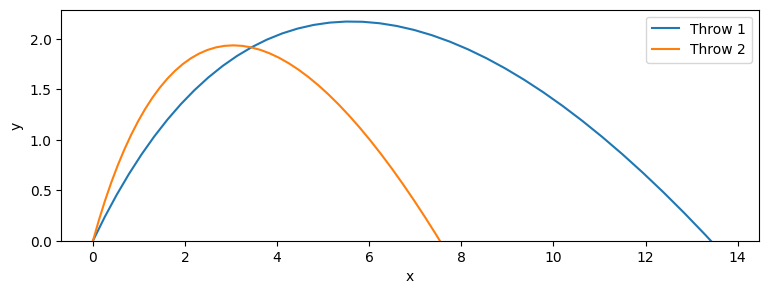

In [4]:
angle1 = 45.0
strength1 = 0.7
gravity1 = 0.05
wind1 = 0.03
friction1 = 0.01
xs1, ys1, ts1 = simulate_np(angle1, strength1, gravity1, wind1, friction1, noisy=False)

angle2 = 60.0
strength2 = 0.5
gravity2 = 0.04
wind2 = 0.02
friction2 = 0.02
xs2, ys2, ts2 = simulate_np(angle2, strength2, gravity2, wind2, friction2, noisy=False)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(xs1, ys1, label="Throw 1")
ax.plot(xs2, ys2, label="Throw 2")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(bottom=0)
ax.legend()
plt.show()


## Summary Statistics

Each throw is compressed into two summary statistics:

1. the inferred landing distance (the $x$ position where the trajectory crosses $y=0$),
2. the flight time until the trajectory reaches $y=0$.


In [6]:
print("Summary stats for Throw 1:", summary_stats(xs1, ys1, ts1))
print("Summary stats for Throw 2:", summary_stats(xs2, ys2, ts2))

Summary stats for Throw 1: [13.417318 18.619087]
Summary stats for Throw 2: [ 7.5327454 19.643105 ]


## Defining the prior distribution

We infer the unknown throw angle $\theta$.
Wind $W$ is sampled from a latent exponential distribution and treated as simulator noise.
The remaining parameters are fixed constants.


In [7]:
print(f"theta ~ Normal(mean={PRIOR_MEAN}, std={PRIOR_STD})")
print(f"W ~ Exponential(rate={WIND_RATE})")
print(f"Fixed strength = {FIXED_STRENGTH}")
print(f"Fixed gravity = {FIXED_GRAVITY}")
print(f"Fixed friction = {FIXED_FRICTION}")


# ## Sampling from the prior, and simulating
#
# We now sample training angles from the prior, sample latent wind values, simulate noisy
# throws, and retain only the two summary statistics for each throw.

key_data, MASTER_KEY = random.split(MASTER_KEY)
t0 = time.time()
theta_train, sum_stats_train, wind_train, done_flags = generate_dataset(
    key_data,
    NUM_SIMULATIONS,
    max_steps=MAX_STEPS,
    chunk_size=1_000,
)
elapsed = time.time() - t0

print("theta_train shape:", theta_train.shape)
print("sum_stats_train shape:", sum_stats_train.shape)
print("All trajectories terminated before MAX_STEPS:", bool(jnp.all(done_flags)))
print(f"Dataset generation time: {elapsed:.2f} s")


theta ~ Normal(mean=35.0, std=15.0)
W ~ Exponential(rate=200.0)
Fixed strength = 0.7
Fixed gravity = 0.05
Fixed friction = 0.1
theta_train shape: (10000, 1)
sum_stats_train shape: (10000, 2)
All trajectories terminated before MAX_STEPS: True
Dataset generation time: 2.50 s


## Prior Predictive Check

We sample angles from the prior, draw latent wind values, and simulate trajectories before
training. The right panel compares simulated landing distances to a synthetic "observed"
distance distribution that is uniform between the 45th and 90th percentiles of the simulated
landing distances.


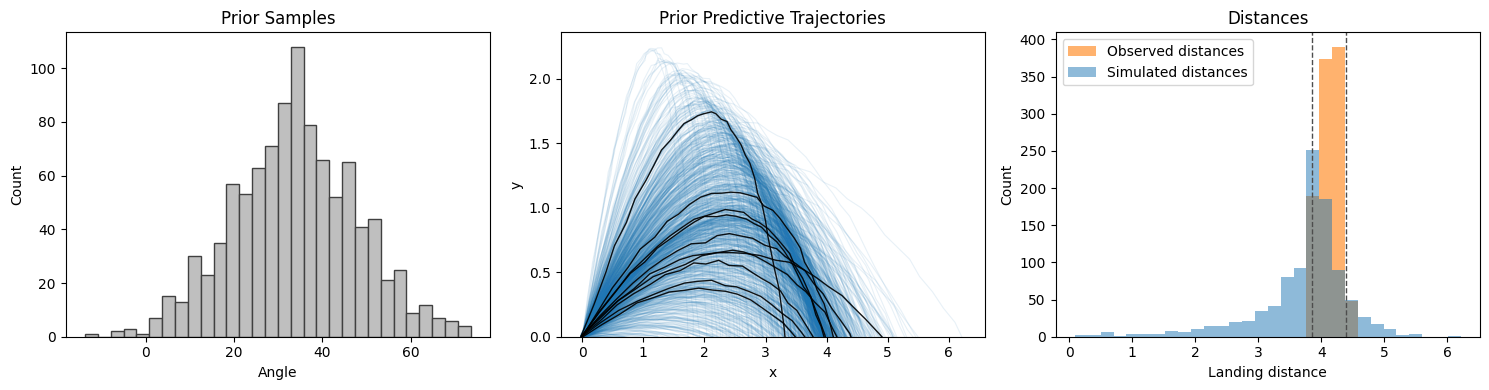

In [9]:
prior_predictive_rng = np.random.default_rng(7)
pp_theta, pp_distances, pp_traces = sample_prior_predictive_trajectories(
    prior_predictive_rng,
    NUM_PRIOR_PREDICTIVE_SAMPLES,
    noisy=True,
)

distance_low, distance_high = np.percentile(pp_distances, [45.0, 90.0])
observed_distances = prior_predictive_rng.uniform(
    distance_low,
    distance_high,
    size=NUM_PRIOR_PREDICTIVE_SAMPLES,
).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(pp_theta, bins=30, color="0.75", edgecolor="0.25")
axes[0].set_title("Prior Samples")
axes[0].set_xlabel("Angle")
axes[0].set_ylabel("Count")

for xs, ys in pp_traces:
    axes[1].plot(xs, ys, color="C0", alpha=0.1, linewidth=0.8)
for xs, ys in pp_traces[:NUM_PRIOR_PREDICTIVE_HIGHLIGHT]:
    axes[1].plot(xs, ys, color="black", alpha=0.9, linewidth=1.0)
axes[1].set_title("Prior Predictive Trajectories")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_ylim(bottom=0)

bins = np.histogram_bin_edges(
    np.concatenate([pp_distances, observed_distances]),
    bins=30,
)
axes[2].hist(
    observed_distances,
    bins=bins,
    color="C1",
    alpha=0.6,
    label="Observed distances",
)
axes[2].hist(
    pp_distances,
    bins=bins,
    color="C0",
    alpha=0.5,
    label="Simulated distances",
)
axes[2].axvline(distance_low, color="0.3", linestyle="--", linewidth=1.0)
axes[2].axvline(distance_high, color="0.3", linestyle="--", linewidth=1.0)
axes[2].set_title("Distances")
axes[2].set_xlabel("Landing distance")
axes[2].set_ylabel("Count")
axes[2].legend()

fig.tight_layout()
plt.show()


We now model the standardized summary vector

$$
x = (\text{landing distance}, \text{flight time}),
$$

and the standardized throw angle

$$
\theta_\mathrm{std} = \frac{\theta - \mu_\theta}{\sigma_\theta}.
$$

The conditional normalizing flow uses a standard Gaussian base variable

$$
u \sim \mathcal{N}(0, 1),
$$

and a monotone spline transform conditioned on the standardized summaries,

$$
\theta_\mathrm{std} = f_\psi(\nu; x_\mathrm{std}).
$$

This gives a tractable amortized posterior density

$$
\log p_\psi(\theta \mid x)
= \log p(\nu) + \log \left|\frac{d\nu}{d\theta_\mathrm{std}}\right| - \log \sigma_\theta.
$$

Training is therefore pure conditional maximum likelihood on simulated pairs `(theta, x)`.


In [10]:
LOG_2PI = np.log(2.0 * np.pi)


def _softplus_inverse(y: float) -> float:
    return float(np.log(np.expm1(y)))


def _unconstrained_spline_params(
    raw_widths: jax.Array,
    raw_heights: jax.Array,
    raw_derivatives: jax.Array,
    bound: float,
    min_bin_width: float = 1e-3,
    min_bin_height: float = 1e-3,
    min_derivative: float = 1e-3,
) -> tuple[jax.Array, jax.Array, jax.Array, jax.Array, jax.Array]:
    num_bins = raw_widths.shape[-1]

    widths = nn.softmax(raw_widths, axis=-1)
    widths = min_bin_width + (2.0 * bound - min_bin_width * num_bins) * widths
    cumwidths = jnp.cumsum(widths, axis=-1)
    cumwidths = jnp.pad(
        cumwidths,
        [(0, 0)] * (cumwidths.ndim - 1) + [(1, 0)],
        constant_values=0.0,
    )
    cumwidths = cumwidths + (-bound)
    cumwidths = cumwidths.at[..., 0].set(-bound)
    cumwidths = cumwidths.at[..., -1].set(bound)

    heights = nn.softmax(raw_heights, axis=-1)
    heights = min_bin_height + (2.0 * bound - min_bin_height * num_bins) * heights
    cumheights = jnp.cumsum(heights, axis=-1)
    cumheights = jnp.pad(
        cumheights,
        [(0, 0)] * (cumheights.ndim - 1) + [(1, 0)],
        constant_values=0.0,
    )
    cumheights = cumheights + (-bound)
    cumheights = cumheights.at[..., 0].set(-bound)
    cumheights = cumheights.at[..., -1].set(bound)

    interior = min_derivative + nn.softplus(raw_derivatives)
    ones = jnp.ones((*interior.shape[:-1], 1), dtype=interior.dtype)
    derivatives = jnp.concatenate([ones, interior, ones], axis=-1)
    return widths, cumwidths, heights, cumheights, derivatives


def _searchsorted(bin_locations: jax.Array, inputs: jax.Array) -> jax.Array:
    idx = jnp.sum(inputs[..., None] >= bin_locations[..., 1:], axis=-1)
    num_bins = bin_locations.shape[-1] - 1
    return jnp.clip(idx, 0, num_bins - 1)


def _gather(arr: jax.Array, idx: jax.Array) -> jax.Array:
    return jnp.take_along_axis(arr, idx[..., None], axis=-1)[..., 0]


def rqs_forward(
    inputs: jax.Array,
    raw_widths: jax.Array,
    raw_heights: jax.Array,
    raw_derivatives: jax.Array,
    *,
    bound: float = 6.0,
    min_bin_width: float = 1e-3,
    min_bin_height: float = 1e-3,
    min_derivative: float = 1e-3,
) -> tuple[jax.Array, jax.Array]:
    widths, cumwidths, heights, cumheights, derivatives = _unconstrained_spline_params(
        raw_widths,
        raw_heights,
        raw_derivatives,
        bound,
        min_bin_width,
        min_bin_height,
        min_derivative,
    )

    inside = (inputs >= -bound) & (inputs <= bound)
    bin_idx = _searchsorted(cumwidths, inputs)

    input_cumwidths = _gather(cumwidths[..., :-1], bin_idx)
    input_bin_widths = _gather(widths, bin_idx)
    input_cumheights = _gather(cumheights[..., :-1], bin_idx)
    input_bin_heights = _gather(heights, bin_idx)
    input_delta = input_bin_heights / input_bin_widths
    input_derivatives = _gather(derivatives[..., :-1], bin_idx)
    input_derivatives_plus_one = _gather(derivatives[..., 1:], bin_idx)

    theta = (inputs - input_cumwidths) / input_bin_widths
    theta = jnp.clip(theta, 0.0, 1.0)
    theta_omt = theta * (1.0 - theta)

    numerator = input_bin_heights * (
        input_delta * theta**2 + input_derivatives * theta_omt
    )
    denominator = input_delta + (
        (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
        * theta_omt
    )
    outputs = input_cumheights + numerator / denominator

    derivative_numerator = input_delta**2 * (
        input_derivatives_plus_one * theta**2
        + 2.0 * input_delta * theta_omt
        + input_derivatives * (1.0 - theta) ** 2
    )
    logabsdet = jnp.log(derivative_numerator) - 2.0 * jnp.log(denominator)

    outputs = jnp.where(inside, outputs, inputs)
    logabsdet = jnp.where(inside, logabsdet, 0.0)
    return outputs, logabsdet


def rqs_inverse(
    inputs: jax.Array,
    raw_widths: jax.Array,
    raw_heights: jax.Array,
    raw_derivatives: jax.Array,
    *,
    bound: float = 6.0,
    min_bin_width: float = 1e-3,
    min_bin_height: float = 1e-3,
    min_derivative: float = 1e-3,
) -> tuple[jax.Array, jax.Array]:
    widths, cumwidths, heights, cumheights, derivatives = _unconstrained_spline_params(
        raw_widths,
        raw_heights,
        raw_derivatives,
        bound,
        min_bin_width,
        min_bin_height,
        min_derivative,
    )

    inside = (inputs >= -bound) & (inputs <= bound)
    bin_idx = _searchsorted(cumheights, inputs)

    input_cumwidths = _gather(cumwidths[..., :-1], bin_idx)
    input_bin_widths = _gather(widths, bin_idx)
    input_cumheights = _gather(cumheights[..., :-1], bin_idx)
    input_bin_heights = _gather(heights, bin_idx)
    input_delta = input_bin_heights / input_bin_widths
    input_derivatives = _gather(derivatives[..., :-1], bin_idx)
    input_derivatives_plus_one = _gather(derivatives[..., 1:], bin_idx)

    shifted = inputs - input_cumheights
    a = shifted * (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
    a = a + input_bin_heights * (input_delta - input_derivatives)
    b = input_bin_heights * input_derivatives
    b = b - shifted * (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
    c = -input_delta * shifted

    discriminant = jnp.maximum(b**2 - 4.0 * a * c, 0.0)
    root_quadratic = (2.0 * c) / (-b - jnp.sqrt(discriminant))
    root_linear = -c / b
    theta = jnp.where(jnp.abs(a) < 1e-6, root_linear, root_quadratic)
    theta = jnp.clip(theta, 0.0, 1.0)

    outputs = theta * input_bin_widths + input_cumwidths

    theta_omt = theta * (1.0 - theta)
    denominator = input_delta + (
        (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
        * theta_omt
    )
    derivative_numerator = input_delta**2 * (
        input_derivatives_plus_one * theta**2
        + 2.0 * input_delta * theta_omt
        + input_derivatives * (1.0 - theta) ** 2
    )
    logabsdet = -(jnp.log(derivative_numerator) - 2.0 * jnp.log(denominator))

    outputs = jnp.where(inside, outputs, inputs)
    logabsdet = jnp.where(inside, logabsdet, 0.0)
    return outputs, logabsdet


def flow_log_prob_standardized(
    theta_std: jax.Array,
    raw_params: tuple[jax.Array, jax.Array, jax.Array],
    *,
    bound: float = 6.0,
) -> jax.Array:
    raw_widths, raw_heights, raw_derivatives = raw_params
    z, logabsdet = rqs_inverse(
        theta_std,
        raw_widths,
        raw_heights,
        raw_derivatives,
        bound=bound,
    )
    log_base = -0.5 * (z**2 + LOG_2PI)
    return log_base + logabsdet


def flow_sample_standardized(
    key: jax.Array,
    raw_params: tuple[jax.Array, jax.Array, jax.Array],
    num_samples: int,
    *,
    bound: float = 6.0,
) -> jax.Array:
    raw_widths, raw_heights, raw_derivatives = raw_params
    if raw_widths.shape[0] != 1:
        raise ValueError("flow_sample_standardized expects a single conditioning context.")

    raw_widths = jnp.repeat(raw_widths, num_samples, axis=0)
    raw_heights = jnp.repeat(raw_heights, num_samples, axis=0)
    raw_derivatives = jnp.repeat(raw_derivatives, num_samples, axis=0)

    z = random.normal(key, shape=(num_samples,), dtype=jnp.float32)
    theta_std, _ = rqs_forward(
        z,
        raw_widths,
        raw_heights,
        raw_derivatives,
        bound=bound,
    )
    return theta_std


class ConditionalSplineFlow(nn.Module):
    num_bins: int = 16
    hidden_features: Tuple[int, ...] = (64, 64)
    bound: float = 6.0
    min_derivative: float = 1e-3

    @nn.compact
    def __call__(self, context: jax.Array) -> tuple[jax.Array, jax.Array, jax.Array]:
        x = context
        for width in self.hidden_features:
            x = nn.swish(nn.Dense(width)(x))

        derivative_bias = _softplus_inverse(1.0 - self.min_derivative)

        raw_widths = nn.Dense(
            self.num_bins,
            kernel_init=nn.initializers.zeros_init(),
            bias_init=nn.initializers.zeros_init(),
        )(x)
        raw_heights = nn.Dense(
            self.num_bins,
            kernel_init=nn.initializers.zeros_init(),
            bias_init=nn.initializers.zeros_init(),
        )(x)
        raw_derivatives = nn.Dense(
            self.num_bins - 1,
            kernel_init=nn.initializers.zeros_init(),
            bias_init=nn.initializers.constant(derivative_bias),
        )(x)
        return raw_widths, raw_heights, raw_derivatives


@dataclass
class PosteriorEstimator:
    model: Any
    params: Any
    x_mean: jax.Array
    x_std: jax.Array
    theta_loc: float = PRIOR_MEAN
    theta_scale: float = PRIOR_STD

    def _standardize_x(self, x: jax.Array) -> jax.Array:
        x = jnp.asarray(x, dtype=jnp.float32)
        return (x - self.x_mean) / self.x_std

    def _raw_params(self, x: jax.Array) -> tuple[jax.Array, jax.Array, jax.Array]:
        x_std = self._standardize_x(x)
        if x_std.ndim == 1:
            x_std = x_std[None, :]
        return self.model.apply({"params": self.params}, x_std)

    def log_prob(self, theta: jax.Array, x: jax.Array) -> jax.Array:
        theta = jnp.asarray(theta, dtype=jnp.float32)
        x = jnp.asarray(x, dtype=jnp.float32)

        if theta.ndim == 0:
            theta = theta[None]
        if theta.ndim == 2 and theta.shape[-1] == 1:
            theta = theta[:, 0]
        if x.ndim == 1:
            x = x[None, :]
        if x.shape[0] == 1 and theta.shape[0] > 1:
            x = jnp.repeat(x, theta.shape[0], axis=0)

        theta_std = (theta - self.theta_loc) / self.theta_scale
        raw_params = self._raw_params(x)
        log_prob_std = flow_log_prob_standardized(
            theta_std,
            raw_params,
            bound=self.model.bound,
        )
        return log_prob_std - jnp.log(self.theta_scale)

    def sample(self, key: jax.Array, num_samples: int, x: jax.Array) -> jax.Array:
        raw_params = self._raw_params(jnp.asarray(x, dtype=jnp.float32))
        theta_std = flow_sample_standardized(
            key,
            raw_params,
            num_samples,
            bound=self.model.bound,
        )
        theta = theta_std * self.theta_scale + self.theta_loc
        return theta[:, None]


def fit_posterior_estimator(
    key: jax.Array,
    theta_all: jax.Array,
    x_all: jax.Array,
    *,
    num_epochs: int = MAX_EPOCHS,
    batch_size: int = BATCH_SIZE,
    learning_rate: float = 1e-3,
    weight_decay: float = 0.0,
    validation_fraction: float = 0.1,
    num_bins: int = 16,
    hidden_features: tuple[int, ...] = (64, 64),
    bound: float = 6.0,
    patience: int = 30,
) -> tuple[PosteriorEstimator, dict[str, list[float]]]:
    theta_all = jnp.asarray(theta_all, dtype=jnp.float32)
    x_all = jnp.asarray(x_all, dtype=jnp.float32)

    n = theta_all.shape[0]
    n_val = max(1, int(n * validation_fraction))
    n_train = n - n_val

    key_perm, key_init, key_epoch = random.split(key, 3)
    perm = np.asarray(random.permutation(key_perm, n))
    theta_all = theta_all[perm]
    x_all = x_all[perm]

    train_theta = theta_all[:n_train]
    train_x = x_all[:n_train]
    val_theta = theta_all[n_train:]
    val_x = x_all[n_train:]

    x_mean = jnp.mean(train_x, axis=0)
    x_std = jnp.std(train_x, axis=0)
    x_std = jnp.where(x_std < 1e-6, 1.0, x_std)

    model = ConditionalSplineFlow(
        num_bins=num_bins,
        hidden_features=hidden_features,
        bound=bound,
    )

    init_x = ((train_x[:1] - x_mean) / x_std).astype(jnp.float32)
    params = model.init(key_init, init_x)["params"]

    tx = optax.chain(
        optax.clip_by_global_norm(5.0),
        optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay),
    )
    state = TrainState.create(apply_fn=model.apply, params=params, tx=tx)

    @jax.jit
    def batch_nll(params: Any, theta_batch: jax.Array, x_batch: jax.Array) -> jax.Array:
        x_batch_std = (x_batch - x_mean) / x_std
        theta_batch_std = (theta_batch[:, 0] - PRIOR_MEAN) / PRIOR_STD
        raw_params = model.apply({"params": params}, x_batch_std)
        log_prob_std = flow_log_prob_standardized(
            theta_batch_std,
            raw_params,
            bound=bound,
        )
        log_prob = log_prob_std - jnp.log(PRIOR_STD)
        return -jnp.mean(log_prob)

    @jax.jit
    def train_step(
        state: TrainState,
        theta_batch: jax.Array,
        x_batch: jax.Array,
    ) -> tuple[TrainState, jax.Array]:
        loss_fn = lambda params: batch_nll(params, theta_batch, x_batch)
        loss, grads = jax.value_and_grad(loss_fn)(state.params)
        state = state.apply_gradients(grads=grads)
        return state, loss

    best_params = state.params
    best_val = float("inf")
    stale_epochs = 0

    history = {"train_nll": [], "val_nll": []}

    for epoch in range(num_epochs):
        key_epoch, key_batch = random.split(key_epoch)
        batch_perm = np.asarray(random.permutation(key_batch, n_train))
        epoch_losses = []

        for start in range(0, n_train, batch_size):
            idx = batch_perm[start : start + batch_size]
            state, loss = train_step(state, train_theta[idx], train_x[idx])
            epoch_losses.append(float(loss))

        train_loss = float(np.mean(epoch_losses))
        val_loss = float(batch_nll(state.params, val_theta, val_x))

        history["train_nll"].append(train_loss)
        history["val_nll"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_params = jax.tree_util.tree_map(lambda x: x.copy(), state.params)
            stale_epochs = 0
        else:
            stale_epochs += 1

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(
                f"epoch {epoch + 1:4d} | "
                f"train nll {train_loss:.4f} | "
                f"val nll {val_loss:.4f}"
            )

        if stale_epochs >= patience:
            print(f"Early stopping at epoch {epoch + 1} (best val nll {best_val:.4f}).")
            break

    posterior = PosteriorEstimator(
        model=model,
        params=best_params,
        x_mean=x_mean,
        x_std=x_std,
    )
    return posterior, history


### Run training

Training uses pure conditional maximum likelihood on simulated `(theta, x)` pairs. The estimator is amortized, so once training is complete we can condition on a fresh observation immediately without any retraining or sampling-based posterior reconstruction.


epoch    1 | train nll 3.3206 | val nll 2.7345
epoch   20 | train nll 0.5478 | val nll 0.9133
epoch   40 | train nll 0.0485 | val nll 0.0109
epoch   60 | train nll 0.0228 | val nll -0.1597
epoch   80 | train nll 0.2400 | val nll 0.3987
Early stopping at epoch 99 (best val nll -0.2394).
Training time: 30.96 s


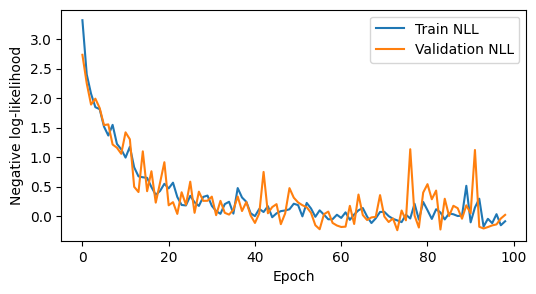

In [11]:
key_train, MASTER_KEY = random.split(MASTER_KEY)

t0 = time.time()
posterior, history = fit_posterior_estimator(
    key_train,
    theta_train,
    sum_stats_train,
    num_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=1e-3,
    patience=25,
)
elapsed = time.time() - t0
print(f"Training time: {elapsed:.2f} s")


fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history["train_nll"], label="Train NLL")
ax.plot(history["val_nll"], label="Validation NLL")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative log-likelihood")
ax.legend()
plt.show()


## Obtain an "Observation"

We now generate a fresh simulated observation that was *not*
used during training. This stands in for observed data. Because the estimator is amortized,
we can condition the trained posterior on this new observation directly, with no retraining.


In [14]:
true_angle = 15.0
true_wind = 0.01

obs_rng = np.random.default_rng(123)
true_x, true_y, true_t = simulate_np(
    true_angle,
    FIXED_STRENGTH,
    FIXED_GRAVITY,
    true_wind,
    FIXED_FRICTION,
    noisy=True,
    rng=obs_rng,
)
true_ss = summary_stats(true_x, true_y, true_t)

print("True summary statistics:", true_ss)

key_post, MASTER_KEY = random.split(MASTER_KEY)
posterior_samples = posterior.sample(key_post, NUM_POSTERIOR_SAMPLES, true_ss)[:, 0]

theta_grid = jnp.linspace(
    float(jnp.min(posterior_samples)) - 3.0,
    float(jnp.max(posterior_samples)) + 3.0,
    400,
    dtype=jnp.float32,
)
posterior_density = jnp.exp(posterior.log_prob(theta_grid, true_ss))

print(
    "Posterior mean ± std:",
    float(jnp.mean(posterior_samples)),
    "±",
    float(jnp.std(posterior_samples)),
)

print("True angle: ",true_angle)

True summary statistics: [3.0436637 5.8322134]
Posterior mean ± std: 15.026991844177246 ± 0.3171525299549103
True angle:  15.0


## Evaluating the Posterior Distribution

The posterior above is encouraging for this one observation, but a single plot is not a
global validation of the inference workflow. As in the original tutorial, we therefore
check

1. posterior predictive consistency, and
2. simulation-based calibration (SBC).

## Posterior Predictive Checks

We sample angles from the posterior, draw latent wind values, simulate new trajectories,
and compare these posterior-predictive throws to the observation.


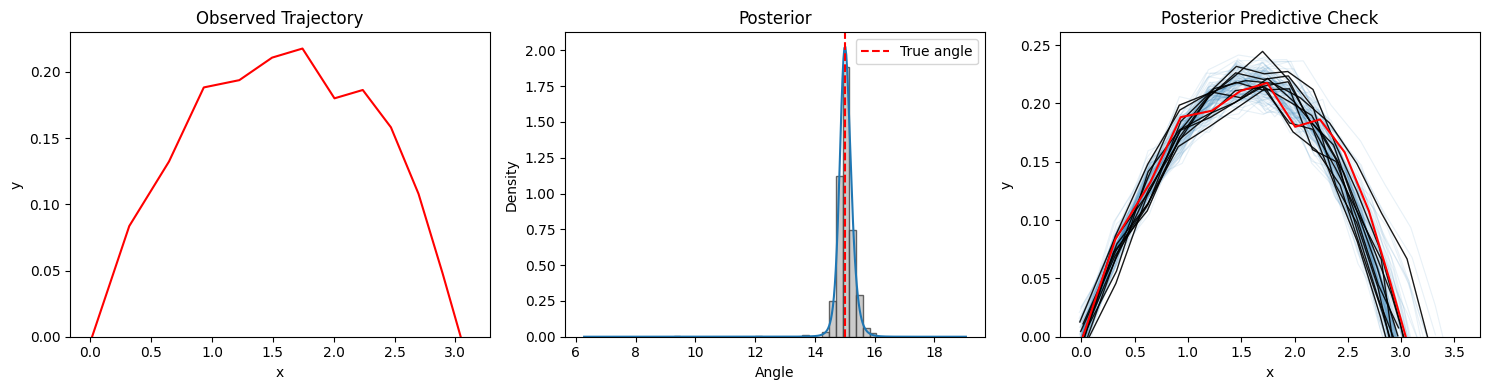

Mean PPC RMSE in summary-statistic space: 0.1145


In [15]:
def posterior_predictive_summary_samples(
    posterior: PosteriorEstimator,
    key: jax.Array,
    x_obs: jax.Array,
    num_samples: int,
) -> tuple[jax.Array, jax.Array]:
    key_theta, key_wind, key_noise = random.split(key, 3)
    theta_samples = posterior.sample(key_theta, num_samples, x_obs)[:, 0]
    wind_samples = sample_latent_wind(key_wind, num_samples)
    noise_keys = random.split(key_noise, num_samples)

    ppc_ss, done = simulate_summary_batch_jit(
        noise_keys,
        theta_samples,
        FIXED_STRENGTH,
        FIXED_GRAVITY,
        wind_samples,
        FIXED_FRICTION,
        dt=DT,
        max_steps=MAX_STEPS,
        noise_std=NOISE_STD,
    )
    return theta_samples, ppc_ss


key_ppc, MASTER_KEY = random.split(MASTER_KEY)
ppc_thetas, ppc_ss = posterior_predictive_summary_samples(
    posterior,
    key_ppc,
    true_ss,
    NUM_PPC_SAMPLES,
)

# For plotting full posterior-predictive trajectories we use the NumPy reference simulator.
ppc_rng = np.random.default_rng(2024)
ppc_traces = []
for theta_sample in np.asarray(ppc_thetas):
    wind_sample = ppc_rng.exponential(scale=1.0 / WIND_RATE)
    xs, ys, _ = simulate_np(
        float(theta_sample),
        FIXED_STRENGTH,
        FIXED_GRAVITY,
        float(wind_sample),
        FIXED_FRICTION,
        noisy=True,
        rng=ppc_rng,
    )
    ppc_traces.append((xs, ys))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(true_x, true_y, color="red", linewidth=1.5)
axes[0].set_title("Observed Trajectory")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_ylim(bottom=0)

axes[1].hist(
    np.asarray(posterior_samples),
    bins=30,
    color="0.75",
    edgecolor="0.25",
    density=True,
    alpha=0.8,
)
axes[1].plot(np.asarray(theta_grid), np.asarray(posterior_density), color="C0", linewidth=1.5)
axes[1].axvline(true_angle, color="red", linestyle="--", linewidth=1.5, label="True angle")
axes[1].set_title("Posterior")
axes[1].set_xlabel("Angle")
axes[1].set_ylabel("Density")
axes[1].set_ylim(bottom=0)
axes[1].legend()

for xs, ys in ppc_traces[NUM_PPC_HIGHLIGHT:]:
    axes[2].plot(xs, ys, color="C0", alpha=0.1, linewidth=0.8, zorder=1)
for xs, ys in ppc_traces[:NUM_PPC_HIGHLIGHT]:
    axes[2].plot(xs, ys, color="black", alpha=0.9, linewidth=1.0, zorder=2)
axes[2].plot(true_x, true_y, color="red", linewidth=1.5, zorder=3)
axes[2].set_title("Posterior Predictive Check")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_ylim(bottom=0)

fig.tight_layout()
plt.show()


rmses = np.sqrt(np.mean((np.asarray(ppc_ss) - true_ss[None, :]) ** 2, axis=1))
rmse = float(np.mean(rmses))
print(f"Mean PPC RMSE in summary-statistic space: {rmse:.4f}")


## Simulation Based Calibration

To assess calibration *globally*, we now repeat the workflow over many simulated
observations. We use the posterior density as the reducing function, which corresponds
to checking expected coverage of highest-posterior-density regions.


In [16]:
def run_sbc_density(
    posterior: PosteriorEstimator,
    key: jax.Array,
    *,
    num_sbc_samples: int,
    num_posterior_samples: int,
) -> dict[str, np.ndarray]:
    key_data, key_loop = random.split(key)
    theta_true, x_obs, _, _ = generate_dataset(
        key_data,
        num_sbc_samples,
        max_steps=MAX_STEPS,
        chunk_size=min(1_000, num_sbc_samples),
    )
    theta_true = theta_true[:, 0]

    u_values = []
    loop_key = key_loop

    for i in range(num_sbc_samples):
        loop_key, key_i = random.split(loop_key)
        posterior_samples = posterior.sample(key_i, num_posterior_samples, x_obs[i])[:, 0]

        logp_true = posterior.log_prob(theta_true[i], x_obs[i])[0]
        logp_samples = posterior.log_prob(posterior_samples, x_obs[i])

        # u_i is the posterior mass lying in regions of *higher* density than the true theta.
        # If the posterior is calibrated, u_i should be Uniform(0, 1).
        u_i = float(jnp.mean(logp_samples > logp_true))
        u_values.append(u_i)

    u_values = np.asarray(u_values)
    levels = np.linspace(0.0, 1.0, 101)
    empirical_coverage = np.asarray([(u_values <= level).mean() for level in levels])

    return {
        "theta_true": np.asarray(theta_true),
        "x_obs": np.asarray(x_obs),
        "u_values": u_values,
        "levels": levels,
        "empirical_coverage": empirical_coverage,
    }


key_sbc, MASTER_KEY = random.split(MASTER_KEY)
sbc_results = run_sbc_density(
    posterior,
    key_sbc,
    num_sbc_samples=NUM_SBC_SAMPLES,
    num_posterior_samples=NUM_SBC_POSTERIOR_SAMPLES,
)


## How to interpret SBC results

Let $u$ denote the posterior mass assigned to regions of *higher* density than the true
parameter. Under a calibrated posterior, $u \sim \mathrm{Uniform}(0, 1)$.

Equivalently, the empirical coverage curve should track the diagonal:

- **above** the diagonal -> the posterior is too broad (**underconfident**),
- **below** the diagonal -> the posterior is too narrow (**overconfident**).


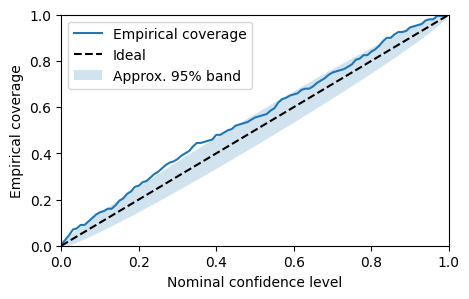

In [17]:
levels = sbc_results["levels"]
coverage = sbc_results["empirical_coverage"]

# Approximate 95% band for the empirical CDF under calibration.
n = NUM_SBC_SAMPLES
band = 1.96 * np.sqrt(levels * (1.0 - levels) / max(n, 1))
lower = np.clip(levels - band, 0.0, 1.0)
upper = np.clip(levels + band, 0.0, 1.0)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(levels, coverage, label="Empirical coverage")
ax.plot(levels, levels, linestyle="--", color="black", label="Ideal")
ax.fill_between(levels, lower, upper, alpha=0.2, label="Approx. 95% band")
ax.set_xlabel("Nominal confidence level")
ax.set_ylabel("Empirical coverage")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.show()
